# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
| --- | --- | --- |
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
| --- | --- |
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---

## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Хвостова Олександра'
ГРУПА = 'ШІ-32'
ВАРІАНТ = 12     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 12 · Хвостова Олександра, ШІ-32, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          5        2         0       5    788
Офсетний папір, кг             1        1         3       6    661
Фарба, кг                      6        3         5       4    458
Друкарська машина, год         2        4         6       0   1005
Різка й фальцювання, год       4        6         2       4    535

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      39       55        36      26

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Різка й фальцювання, год
  ціна:   5.0 за одиницю
  обсяг:  до 762 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---

# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1

Заповніть у клітинці нижче:

- **змінні рішення** — що саме ви обираєте і в яких одиницях;
- **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
- **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
- **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280 (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення (тис. прим./тиждень):

`x1` — Буклет, `x2` — Каталог, `x3` — Календар, `x4` — Плакат.

Цільова функція (прибуток, у.о./тиждень):

`Z = 39·x1 + 55·x2 + 36·x3 + 26·x4 → max`

Обмеження (по одному на ресурс):

```
5·x1 + 2·x2 + 0·x3 + 5·x4 ≤ 788    (крейдований папір, кг)
1·x1 + 1·x2 + 3·x3 + 6·x4 ≤ 661    (офсетний папір, кг)
6·x1 + 3·x2 + 5·x3 + 4·x4 ≤ 458    (фарба, кг)
2·x1 + 4·x2 + 6·x3 + 0·x4 ≤ 1005   (друкарська машина, год)
4·x1 + 6·x2 + 2·x3 + 4·x4 ≤ 535    (різка й фальцювання, год)
```

Невід'ємність: `x1, x2, x3, x4 ≥ 0`.

### Завдання 1.2 — питання на розуміння

Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас `b_i` — це те, що підприємство *має* на початок періоду, воно його не обирає: рішення ухвалює
керівник лише щодо того, скільки виробів випускати (`x_j`). Тому `b_i` — параметр моделі (права частина
обмеження), а `x_j` — змінні рішення.

Якби ресурс можна було докупити в будь-якій кількості, то в модель додалася б нова змінна `y_i ≥ 0` —
обсяг закупівлі. Обмеження стало б `Σ a_ij·x_j ≤ b_i + y_i`, а в цільову функцію додався б доданок `−p_i·y_i`
(ціна закупівлі). Запас перестав би бути «стелею»: задача сама вирішувала б, скільки докупити, і докуповувала
б доти, доки тіньова ціна ресурсу перевищує його ціну `p_i`

---

# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1

Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 73.2917, 47.625, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 5745.54                    # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 73.2917, 47.625, 0] | прибуток 5745.54


---

# Етап 3. Розв'язання в Python

### Завдання 3.1

Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
!pip install linprog

In [6]:
r = linprog(-c, A_ub=A, b_ub=b, method='highs')
assert r.success, r.message
план = r.x
прибуток = -r.fun

print('план (тис. прим./тиждень):')
for назва, значення in zip(вироби, план):
    print('  %-9s %9.4f' % (назва, значення))
print('прибуток: %.4f' % прибуток)

план (тис. прим./тиждень):
  Буклет       0.0000
  Каталог     73.2917
  Календар    47.6250
  Плакат       0.0000
прибуток: 5745.5417


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [7]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---

# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
| --- | --- | --- | --- | --- | --- |
| Крейдований папір, кг | 146,5833 | 0 | 788 | 1E+30 | 641,4167 |
| Офсетний папір, кг | 216,1667 | 0 | 661 | 1E+30 | 444,8333 |
| **Фарба, кг** | 458 | **4,4167** | 458 | 365,2143 | 190,5 |
| Друкарська машина, год | 578,9167 | 0 | 1005 | 1E+30 | 426,0833 |
| **Різка й фальцювання, год** | 535 | **6,9583** | 535 | 381 | 351,8 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

- **У дефіциті** — *Фарба* та *Різка й фальцювання*. «Кінцеве значення» дорівнює «Правій частині»
  (ресурс витрачено повністю), а **тіньова ціна додатна** (4,4167 та 6,9583): додаткова одиниця цього ресурсу
  збільшила б прибуток.
- **У надлишку** — *Крейдований папір, Офсетний папір, Друкарська машина*. Кінцеве значення менше за праву
  частину, тіньова ціна = 0: додатковий запас прибутку не дасть, бо ресурс і так не використано повністю.
  Невикористаний залишок дорівнює «допустимому зменшенню» (напр., 788 − 146,5833 = 641,4167), а допустиме
  збільшення — «1E+30», тобто необмежене.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
| --- | --- | --- | --- | --- | --- |
| Буклет | 0 | −15,3333 | 39 | 15,3333 | 1E+30 |
| Каталог | 73,2917 | 0 | 55 | 53 | 33,4 |
| Календар | 47,625 | 0 | 36 | 55,6667 | 15,3333 |
| Плакат | 0 | −19,5 | 26 | 19,5 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Якийсь саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

- Не виробляються **два** вироби: *Буклет* і *Плакат*.
- **Буклет**: зведена вартість −15,3333 → прибуток з одиниці має зрости більше ніж на **15,33** (з 39 до понад 54,33).
  **Плакат**: −19,5 → більше ніж на **19,5** (з 26 до понад 45,5). Найближчий до входу в план — Буклет.
- Число береться зі звіту, з колонки «Зведена вартість» (його модуль збігається з «допустимим збільшенням» у тому ж рядку:
  для змінної поза планом цільовий коефіцієнт можна збільшувати до цієї межі, і план не зміниться).
- Зведена вартість = прибуток виробу мінус вартість ресурсів, які він забирає, за тіньовими цінами.

  Буклет: `39 − (6·4,4167 + 4·6,9583) = 39 − 26,5 − 27,8333 = −15,3333`.

  Плакат: `26 − (4·4,4167 + 4·6,9583) = 26 − 17,6667 − 27,8333 = −19,5`.
  Тобто на виготовлення одиниці Буклета «йде» ресурсів на 54,33 у.о. (за їхньою внутрішньою цінністю), а приносить він лише 39.

---

# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1

Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
ТІНЬОВА_ЗВІТ = np.array([0, 0, 4.416667, 0, 6.958333])
k = int(np.argmax(ТІНЬОВА_ЗВІТ))           # найдорожчий ресурс
print('найдорожчий ресурс:', ресурси[k], '| тіньова ціна зі звіту:', ТІНЬОВА_ЗВІТ[k])

b_плюс1 = b.copy()
b_плюс1[k] += 1
r1 = linprog(-c, A_ub=A, b_ub=b_плюс1, method='highs')
прибуток_плюс1 = -r1.fun
приріст = прибуток_плюс1 - прибуток
print('прибуток: %.4f -> %.4f' % (прибуток, прибуток_плюс1))
print('приріст: %.4f | тіньова ціна зі звіту: %.4f' % (приріст, ТІНЬОВА_ЗВІТ[k]))

найдорожчий ресурс: Різка й фальцювання, год | тіньова ціна зі звіту: 6.958333
прибуток: 5745.5417 -> 5752.5000
приріст: 6.9583 | тіньова ціна зі звіту: 6.9583


**Відповідь 5.1:** приріст прибутку = **6,9583** (з 5745,5417 до 5752,5), тіньова ціна зі звіту = **6,9583** — **збігаються**.
Отже, одна додаткова одиниця ресурсу «Різка й фальцювання» дає рівно 6,9583 у.о. прибутку, як і стверджує звіт.

### Завдання 5.2

Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

приріст = тіньова ціна для перших 381 одиниць; на кроці 381 -> 382 приріст = 0.0000
допустиме збільшення зі звіту Excel: 381 | знайдена межа: 381


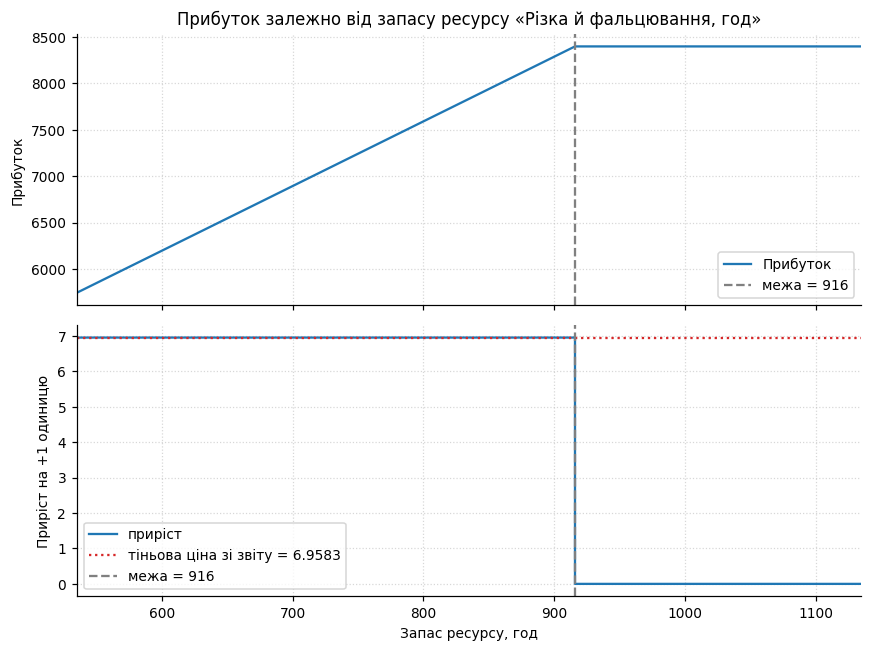

In [9]:
кроки = np.arange(0, 601)
прибутки = []
for додаток in кроки:
    bb = b.copy()
    bb[k] += додаток
    прибутки.append(-linprog(-c, A_ub=A, b_ub=bb, method='highs').fun)
прибутки = np.array(прибутки)
прирости = np.diff(прибутки)

# межа діапазону: перший крок, де приріст перестає дорівнювати тіньовій ціні
злам = int(np.argmax(~np.isclose(прирости, ТІНЬОВА_ЗВІТ[k], atol=1e-6)))
print('приріст = тіньова ціна для перших %d одиниць; на кроці %d -> %d приріст = %.4f' %
      (злам, злам, злам + 1, прирости[злам]))
print('допустиме збільшення зі звіту Excel: 381 | знайдена межа: %d' % злам)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 1. Прибуток
ax1.plot(b[k] + кроки, прибутки, color='C0', label='Прибуток')
ax1.axvline(b[k] + злам, color='grey', ls='--', label='межа = %d' % (b[k] + злам))
ax1.set_ylabel('Прибуток')
ax1.set_title('Прибуток залежно від запасу ресурсу «%s»' % ресурси[k])
ax1.legend(loc='lower right')
ax1.grid(True, ls=':', alpha=0.5)

# 2. Приріст 
ax2.step(b[k] + кроки[:-1], прирости, where='post', color='C0', label='приріст')
ax2.axhline(ТІНЬОВА_ЗВІТ[k], color='C3', ls=':', label='тіньова ціна зі звіту = %.4f' % ТІНЬОВА_ЗВІТ[k])
ax2.axvline(b[k] + злам, color='grey', ls='--', label='межа = %d' % (b[k] + злам))
ax2.set_xlabel('Запас ресурсу, год')
ax2.set_ylabel('Приріст на +1 одиницю')
ax2.set_xlim(b[k], b[k] + кроки[-1]) 
ax2.legend(loc='lower left')
ax2.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Відповідь 5.2:** Тіньова ціна 6,9583 діє, поки запас зростає **на 381 одиницю** (з 535 до 916). Далі приріст
падає до нуля (на нижньому графіку — горизонтальна ділянка, потім злам). Знайдена межа **збігається** з «допустимим
збільшенням» = 381 у рядку «Різка й фальцювання» звіту Excel.

---

# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1

Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
ресурс_п = V['ресурс_пропозиції']
ціна_п   = V['ціна_пропозиції']
обсяг_п  = V['обсяг_пропозиції']
тіньова  = ТІНЬОВА_ЗВІТ[ресурс_п]
доп_збільшення = 381

print('ресурс:', ресурси[ресурс_п], '| ціна: %.1f | пропонують: %d | тіньова ціна: %.4f' % (ціна_п, обсяг_п, тіньова))
print('1) брати? тіньова %.4f > ціна %.1f -> %s' % (тіньова, ціна_п, 'ТАК' if тіньова > ціна_п else 'НІ'))

кількість = min(обсяг_п, доп_збільшення) if тіньова > ціна_п else 0
виграш_оцінка = (тіньова - ціна_п) * кількість
print('2) скільки брати: min(%d, %d) = %d' % (обсяг_п, доп_збільшення, кількість))
print('3) очікуваний виграш: (%.4f - %.1f) * %d = %.4f' % (тіньова, ціна_п, кількість, виграш_оцінка))

def чистий_виграш(q):
    bb = b.copy(); bb[ресурс_п] += q
    return -linprog(-c, A_ub=A, b_ub=bb, method='highs').fun - прибуток - ціна_п * q

print('\nперевірка прямим розв\'язанням: %.4f' % чистий_виграш(кількість))
print('якщо взяти все, що пропонують (%d): %.4f' % (обсяг_п, чистий_виграш(обсяг_п)))
краще = max(range(обсяг_п + 1), key=чистий_виграш)
print('найкраща кількість перебором 0..%d: %d (виграш %.4f)' % (обсяг_п, краще, чистий_виграш(краще)))

ресурс: Різка й фальцювання, год | ціна: 5.0 | пропонують: 762 | тіньова ціна: 6.9583
1) брати? тіньова 6.9583 > ціна 5.0 -> ТАК
2) скільки брати: min(762, 381) = 381
3) очікуваний виграш: (6.9583 - 5.0) * 381 = 746.1249

перевірка прямим розв'язанням: 746.1250
якщо взяти все, що пропонують (762): -1158.8750
найкраща кількість перебором 0..762: 381 (виграш 746.1250)


**Відповідь 6.1:**

- **Брати чи ні і чому:** **Брати.** Тіньова ціна ресурсу «Різка й фальцювання» — 6,9583 у.о. за одиницю, а постачальник просить лише 5,0.
  Кожна куплена одиниця приносить 6,9583 прибутку і коштує 5,0, тобто дає чисті **+1,9583**.
- **Скільки одиниць має сенс купити і чому не більше:** **381**, а не 762. Тіньова ціна 6,9583 діє тільки в межах
  допустимого збільшення (+381, до запасу 916). Після цього план упирається в інші ресурси (фарбу), додаткове різання
  вже нічого не дає (тіньова ціна 0), а платити 5,0 за кожну зайву одиницю доводиться.
- **Очікуваний виграш:** `(6,9583 − 5,0) · 381 = 746,125` у.о. на тиждень.
- **Перевірка прямим розв'язанням дала:** прибуток із запасом 916 = 8396,67; `8396,67 − 5745,54 − 5·381 = 746,125` — збігається з оцінкою.
  Якщо ж взяти всі 762 одиниці, прибуток не зросте більше, а витрати виростуть: чистий результат **−1158,875**.
  Перебір усіх кількостей від 0 до 762 теж дає найкращий результат саме при 381.

---

# Етап 7. Перевірка розв'язку

### Завдання 7.1

Порахуйте дві величини:

- скільки виробів мають **ненульовий** випуск;
- скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [11]:
ненульових = int((план > 1e-9).sum())                # виробів із ненульовим випуском
звязних = int(((b - A @ план) < 1e-9).sum())          # ресурсів, витрачених повністю (залишок 0)
print('ненульових:', ненульових, '| зв’язних:', звязних)

ненульових: 2 | зв’язних: 2


In [12]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** Числа збіглися: **2 ненульові змінні** (Каталог, Календар) і **2 зв'язні обмеження** (Фарба, Різка й фальцювання).
Оптимальний розв'язок — вершина області допустимих планів, у якій «працюють» стільки змінних, скільки обмежень зв'язні. Якби ненульових було **менше**, ніж зв'язних, розв'язок був би **виродженим**: якась базисна змінна
дорівнює нулю, тіньові ціни й діапазони стають неоднозначними (звіт залежить від вибору базису). А якби ненульових було **більше**, ніж зв'язних, це означало б, що розв'язок не є вершиною — тобто помилку в розв'язанні або в моделі.

---

# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1

Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [13]:
# 1 без умови цілочисельності
x_lp = план
# 2 округлений план і перевірка допустимості
x_округл = np.round(x_lp)
використано = A @ x_округл
допустимий = bool(np.all(використано <= b + 1e-9))
print('округлений план:', x_округл, '| прибуток формально: %.1f' % (c @ x_округл))
print('витрати ресурсів:', використано)
print('запаси:          ', b)
print('перевищення:     ', np.maximum(використано - b, 0), '| допустимий:', допустимий)

# для порівняння — округлення вниз 
x_вниз = np.floor(x_lp + 1e-9)
print('\nокруглення вниз:', x_вниз, '| прибуток: %.1f' % (c @ x_вниз), '| допустимий:', bool(np.all(A @ x_вниз <= b + 1e-9)))

# 3 справжній цілочисельний оптимум
r_int = linprog(-c, A_ub=A, b_ub=b, method='highs', integrality=np.ones(len(c)))
x_int = np.round(r_int.x)
print('\nцілочисельний оптимум:', x_int, '| прибуток: %.1f' % (-r_int.fun), '| допустимий:', bool(np.all(A @ x_int <= b + 1e-9)))
print('втрата відносно LP: %.2f (%.2f%%)' % (прибуток + r_int.fun, (прибуток + r_int.fun) / прибуток * 100))

округлений план: [ 0. 73. 48.  0.] | прибуток формально: 5743.0
витрати ресурсів: [146. 217. 459. 580. 534.]
запаси:           [ 788.  661.  458. 1005.  535.]
перевищення:      [0. 0. 1. 0. 0.] | допустимий: False

округлення вниз: [ 0. 73. 47.  0.] | прибуток: 5707.0 | допустимий: True

цілочисельний оптимум: [ 1. 73. 46.  0.] | прибуток: 5710.0 | допустимий: True
втрата відносно LP: 35.54 (0.62%)


**Відповідь 8.1:**

| Варіант | План (Буклет, Каталог, Календар, Плакат) | Прибуток | Допустимий? |
| --- | --- | --- | --- |
| без умови цілочисельності | 0; 73,2917; 47,625; 0 | 5745,54 | так |
| округлений (до найближчого) | 0; 73; 48; 0 | 5743 (формально) | **ні** — фарби 459 > 458 |
| округлення вниз (для порівняння) | 0; 73; 47; 0 | 5707 | так |
| цілочисельний оптимум | 1; 73; 46; 0 | 5710 | так |

**Висновок:** Просто округлювати не можна. Округлення до найближчого дало 48 календарів, і на них не вистачає
фарби (потрібно 459 кг при запасі 458) — план **недопустимий**, хоч «формальний» прибуток 5743 виглядає майже як
оптимум. Округлення вниз завжди допустиме, але неоптимальне (5707). Справжній цілочисельний оптимум (5710) має іншу
структуру: у ньому з'являється 1 буклет, якого в дробовому плані не було, — тобто найкращий цілий план не є сусідом
дробового. Втрата від цілочисельності відносно дробового оптимуму невелика (≈35,5 у.о., 0,6 %), але число
вироби мали б визначатись саме цілочисельною задачею.

---

# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1

Сформуйте власні дані:

- **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
- **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
- **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
- **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [14]:
постачальники = ['Харків', 'Вінниця', 'Одеса']
споживачі     = ['Олександрія', 'Львів', 'Енергодар', 'Київ']

D = np.array([[ 360, 1010,  400, 480],     # Харків    -> ...
              [ 400,  360,  590, 265],     # Вінниця   -> ...
              [ 450,  790,  560, 475]],    # Одеса     -> ...
             dtype=float)
запас = [20, 30, 25]          # тис. од. в кожного постачальника
попит = [15, 20, 25, 15]      # тис. од. у кожного споживача

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Олександрія,Львів,Енергодар,Київ
Харків,360.0,1010.0,400.0,480.0
Вінниця,400.0,360.0,590.0,265.0
Одеса,450.0,790.0,560.0,475.0


---

# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1

Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [15]:
# Розв'язок 1: scipy.optimize.linprog (HiGHS), змінні x[i,j] -> вектор довжини 12
m3, n4 = D.shape
Aeq = np.zeros((m3 + n4, m3 * n4))
for i in range(m3):
    for j in range(n4):
        Aeq[i, i * n4 + j] = 1          # рядок постачальника i: сума перевезень з i
        Aeq[m3 + j, i * n4 + j] = 1     # рядок споживача j: сума перевезень до j
beq = np.array(запас + попит, float)

r_t1 = linprog(D.ravel(), A_eq=Aeq, b_eq=beq, method='highs')
assert r_t1.success, r_t1.message
X1 = r_t1.x.reshape(m3, n4)
вартість1 = r_t1.fun
двоїсті1 = r_t1.eqlin.marginals         # тіньові ціни: 3 постачальники + 4 споживачі

print('РОЗВ\'ЯЗОК 1 — linprog(highs)')
print(pd.DataFrame(X1, index=постачальники, columns=споживачі).round(3).to_string())
print('сумарна вартість:', вартість1)
print('тіньові ціни постачальників:', {n: float(v) + 0.0 for n, v in zip(постачальники, двоїсті1[:3].round(3))})
print('тіньові ціни споживачів:    ', {n: float(v) + 0.0 for n, v in zip(споживачі, двоїсті1[3:].round(3))})

РОЗВ'ЯЗОК 1 — linprog(highs)
         Олександрія  Львів  Енергодар  Київ
Харків           0.0    0.0       20.0   0.0
Вінниця          0.0   20.0        0.0  10.0
Одеса           15.0    0.0        5.0   5.0
сумарна вартість: 29775.0
тіньові ціни постачальників: {'Харків': 410.0, 'Вінниця': 360.0, 'Одеса': 570.0}
тіньові ціни споживачів:     {'Олександрія': -120.0, 'Львів': 0.0, 'Енергодар': -10.0, 'Київ': -95.0}


In [16]:
def розв_pulp():
    задача = pulp.LpProblem('transport', pulp.LpMinimize)
    x = pulp.LpVariable.dicts('x', (range(m3), range(n4)), lowBound=0)
    задача += pulp.lpSum(D[i][j] * x[i][j] for i in range(m3) for j in range(n4))
    for i in range(m3):
        задача += pulp.lpSum(x[i][j] for j in range(n4)) == запас[i], 'S%d' % i
    for j in range(n4):
        задача += pulp.lpSum(x[i][j] for i in range(m3)) == попит[j], 'C%d' % j
    задача.solve(pulp.PULP_CBC_CMD(msg=0))
    X = np.array([[x[i][j].value() for j in range(n4)] for i in range(m3)])
    pi = np.array([задача.constraints['S%d' % i].pi for i in range(m3)] +
                  [задача.constraints['C%d' % j].pi for j in range(n4)])
    return X, pulp.value(задача.objective), pi, 'pulp (CBC)'

def розв_без_зайвого():
    r = linprog(D.ravel(), A_eq=Aeq[:-1], b_eq=beq[:-1], method='highs-ds')
    assert r.success, r.message
    pi = np.append(r.eqlin.marginals, 0.0)     # двоїста змінна викресленого рівняння = 0
    return r.x.reshape(m3, n4), r.fun, pi, 'linprog(highs-ds), 6 незалежних рівнянь'

try:
    if not ПУЛП:
        raise ImportError
    X2, вартість2, двоїсті2, засіб2 = розв_pulp()
except Exception:
    X2, вартість2, двоїсті2, засіб2 = розв_без_зайвого()

print('РОЗВ\'ЯЗОК 2 —', засіб2)
print(pd.DataFrame(X2, index=постачальники, columns=споживачі).round(3).to_string())
print('сумарна вартість:', вартість2)
print('тіньові ціни постачальників:', {n: float(v) + 0.0 for n, v in zip(постачальники, np.round(двоїсті2[:3], 3))})
print('тіньові ціни споживачів:    ', {n: float(v) + 0.0 for n, v in zip(споживачі, np.round(двоїсті2[3:], 3))})

РОЗВ'ЯЗОК 2 — pulp (CBC)
         Олександрія  Львів  Енергодар  Київ
Харків           0.0    0.0       20.0   0.0
Вінниця          0.0   20.0        0.0  10.0
Одеса           15.0    0.0        5.0   5.0
сумарна вартість: 29775.0
тіньові ціни постачальників: {'Харків': 290.0, 'Вінниця': 240.0, 'Одеса': 450.0}
тіньові ціни споживачів:     {'Олександрія': 0.0, 'Львів': 120.0, 'Енергодар': 110.0, 'Київ': 25.0}


### Завдання 10.2 — головне питання цієї частини

Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [17]:
різниця = двоїсті2 - двоїсті1
print('вартості:', вартість1, вартість2, '| збігаються:', np.isclose(вартість1, вартість2))
print('плани збігаються:', np.allclose(X1, X2, atol=1e-6))
print('різниця по постачальниках:', np.round(різниця[:3], 6))
print('різниця по споживачах:    ', np.round(різниця[3:], 6))

k_пост, k_спож = різниця[:3], різниця[3:]
print('\nвсі різниці постачальників однакові:', np.allclose(k_пост, k_пост[0]))
print('всі різниці споживачів однакові:      ', np.allclose(k_спож, k_спож[0]))
print('вони протилежні за знаком (k і -k):   ', np.isclose(k_пост[0], -k_спож[0]), '| k =', round(k_пост[0], 4))

S1 = двоїсті1[:3, None] + двоїсті1[None, 3:]
S2 = двоїсті2[:3, None] + двоїсті2[None, 3:]
print('матриці u_i + v_j однакові:', np.allclose(S1, S2))
print('ранг матриці обмежень:', np.linalg.matrix_rank(Aeq), 'із', Aeq.shape[0], 'рівнянь')
print('\nзведені вартості D - (u_i + v_j) (0 на маршрутах плану):')
print(pd.DataFrame(D - S1, index=постачальники, columns=споживачі).round(3).to_string())

вартості: 29775.0 29775.0 | збігаються: True
плани збігаються: True
різниця по постачальниках: [-120. -120. -120.]
різниця по споживачах:     [120. 120. 120. 120.]

всі різниці постачальників однакові: True
всі різниці споживачів однакові:       True
вони протилежні за знаком (k і -k):    True | k = -120.0
матриці u_i + v_j однакові: True
ранг матриці обмежень: 6 із 7 рівнянь

зведені вартості D - (u_i + v_j) (0 на маршрутах плану):
         Олександрія  Львів  Енергодар   Київ
Харків          70.0  600.0        0.0  165.0
Вінниця        160.0    0.0      240.0    0.0
Одеса            0.0  220.0        0.0    0.0


- **Вартість та план:** Повністю збігаються — вартість становить 29 775 (км·тис. од.), плани перевезень ідентичні.
- **Тіньові ціни:** Не збіглися.
- **Причина та закономірність:** задача збалансована (Σзапасів = Σпопиту = 75), тому одне з 7 рівнянь є наслідком решти, ранг
  матриці обмежень дорівнює 6, а не 7. Двоїста система `u_i + v_j = c_ij` (для маршрутів плану) має 6 рівнянь на
  7 невідомих, тобто безліч розв'язків: одну «ступінь свободи» кожен розв'язувач закріплює довільно. Додавання k до всіх u і віднімання k від усіх v не змінює жодної суми
  `u_i + v_j`, тому всі рівняння й обмеження виконуються однаково.
- **Що це означає для прийняття рішень:** Обидва розв'язки однаково правильні Окремо тіньову ціну постачальника $u_i$ чи споживача $v_j$ інтерпретувати не можна — вона залежить від технічного калібрування програмою.Реальний економічний зміст мають лише суми $u_i + v_j$ (вартість одночасного збільшення запасу і попиту) та різниці між однаковими вузлами. Змінювати лише запас без зміни попиту в закритій задачі неможливо через порушення балансу.

---

# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1

Порахуйте для транспортної задачі те саме, що на етапі 7:

- кількість **ненульових перевезень**;
- кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [18]:
X = X1
ненульових_т = int((X > 1e-9).sum())
зв_т = int((np.abs(Aeq @ X.ravel() - beq) < 1e-9).sum())    # рівність завжди «зв'язна»
print('ненульових перевезень:', ненульових_т)
print('зв’язних обмежень:    ', зв_т, 'із', m3 + n4)
print('ранг матриці обмежень:', np.linalg.matrix_rank(Aeq))
print('різниця (обмежень − ненульових):', зв_т - ненульових_т)

ненульових перевезень: 6
зв’язних обмежень:     7 із 7
ранг матриці обмежень: 6
різниця (обмежень − ненульових): 1


**Відповідь 11.1:**

- **Ненульових перевезень:** 6.
- **Зв'язних обмежень:** 7 (усі; `3 + 4 = 7`).
- **Чому в транспортній задачі зв'язними виявляються всі обмеження:** усі обмеження — **рівності** (запас вивозять повністю, попит
  задовольняють повністю), тож «залишку» немає і кожне з них є зв'язним за означенням. На відміну від виробничої задачі з
  нерівностями (де зв'язні лише дефіцитні ресурси), порівняння «ненульові = зв'язні» тут нічого не перевіряє.
- **На скільки ненульових перевезень менше і чому саме на стільки:** на **1** (6 замість 7). Через баланс `Σзапасів = Σпопиту`
  одне рівняння є наслідком інших, ранг матриці обмежень = 6 = `m + n − 1`. Базисний розв'язок має не більше стільки
  ненульових змінних, який ранг.

### Завдання 11.2 — візуалізація

Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

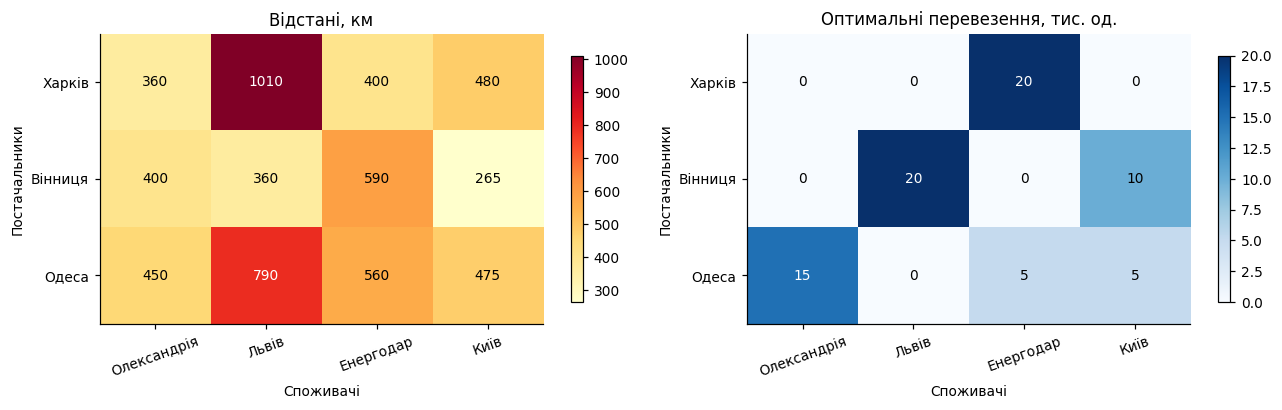

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, дані, назва, cmap, fmt in [(ax1, D, 'Відстані, км', 'YlOrRd', '%d'),
                                    (ax2, X1, 'Оптимальні перевезення, тис. од.', 'Blues', '%g')]:
    im = ax.imshow(дані, cmap=cmap, aspect='auto')
    ax.set_xticks(range(n4)); ax.set_xticklabels(споживачі, rotation=20)
    ax.set_yticks(range(m3)); ax.set_yticklabels(постачальники)
    ax.set_xlabel('Споживачі'); ax.set_ylabel('Постачальники')
    ax.set_title(назва)
    for i in range(m3):
        for j in range(n4):
            v = дані[i, j]
            ax.text(j, i, fmt % v, ha='center', va='center',
                    color='white' if v > дані.max() * 0.6 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

**Висновок:** Вантаж іде переважно найкоротшими маршрутами (Вінниця → Львів і Київ, Одеса → Олександрія, Харків → Енергодар), а найдовші
(на кшталт Харків → Львів, 1010 км) не використовуються зовсім — на другій карті ненульових комірок лише 6 із 12.

---

# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [20]:
ІНСТРУМЕНТИ_ШІ = 'Claude (Anthropic)'

# Заповнено за фактом: код і тексти цієї роботи створені за допомогою Claude.
# Якщо ви щось переписали чи зробили самі (наприклад, Excel), змініть відповідне значення.
ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'текст, перероблено',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# ЗАПОВНІТЬ САМІ (мінімум 120 символів): що саме ви перевірили за згенерованим кодом і текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = ("Перевірено збіг оптимальних значень цільової функції між Excel та Python (linprog). "
    "Перевірено розрахунок тіньових цін і межу допустимого збільшення ресурсу, "
    "виправлено зсув кроків на графіках приросту прибутку."
    "У транспортній задачі перевірено вартість 29 775, суми u_i + v_j та інваріантність "
    "двоїстих оцінок при зсуві на константу k.")

# Поставте True лише коли справді можете пояснити кожен рядок коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [21]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Хвостова Олександра
інструменти:                               Claude (Anthropic)
------------------------------------------------------------------------------
етап 1, формалізація моделі:               текст, перероблено
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Перевірено збіг оптимальних значень цільової функції між Excel та Python (linprog). Перевірено розрахунок тіньових цін і межу допустимого збільшення ресурсу, виправлено зсув кроків на графіках приросту прибутку.У транспортній задачі перевірено вартість 29 7

---

# Крок 13. Фінальна самоперевірка

In [ ]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
